<a href="https://colab.research.google.com/github/dschlesinger/cuda-kernel-demo/blob/main/CUDA_kernel_elem_addition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Need an older version of numba-cuda for the T4, restart after running this
!pip install numba-cuda==0.4.0

### Utils

In [1]:
# Claude generated

import matplotlib.pyplot as plt
import numpy as np, math
from timeit import repeat
from typing import Callable, Optional, Tuple

def run_time_test(x: Callable, n: int = 500, show_plot: bool = True,
                  ax: Optional[plt.Axes] = None, label: str = None,
                  alpha: float = 0.7, color: str = None, per_repeat_n: int = 10_000,
                  ) -> Tuple[plt.Figure, plt.Axes]:
    """
    Run timing tests and plot histogram on a subplot.

    Args:
        x: Function to test
        n: Number of runs
        show_plot: Whether to display the plot
        ax: Existing axes to plot on (if None, creates new figure)
        label: Label for the histogram (useful for legends)
        alpha: Transparency for histogram bars
        color: Color for histogram bars

    Returns:
        Tuple of (figure, axes) objects
    """

    # Run warm ups
    _ = repeat(x, repeat=n // 10, number=per_repeat_n)

    # collect runtimes
    times = np.array(repeat(x, repeat=n, number=per_repeat_n))

    # create figure/axes if not provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    else:
        fig = ax.get_figure()

    # plot histogram
    ax.hist(times, bins=n // 10, edgecolor="black", alpha=alpha,
            label=label, color=color)
    ax.set_title(f"Runtime distribution over {n} runs")
    ax.set_xlabel("Time (seconds)")
    ax.set_ylabel("Frequency")

    # add legend if label provided
    if label:
        ax.legend()

    # compute statistics
    mean = np.mean(times)
    std = np.std(times)
    median = np.median(times)
    tmin = np.min(times)
    tmax = np.max(times)

    # print stats with label if provided
    prefix = f"[{label}] " if label else ""
    print(f"{prefix}{'Mean':^8}: {mean:.6e} s", end=' ')
    print(f"{'Median':^8}: {median:.6e} s", end=' ')
    print(f"{'Std Dev':^8}: {std:.6e} s", end=' ')
    print()
    print(f"{prefix}{'Min':^8}: {tmin:.6e} s", end=' ')
    print(f"{'Max':^8}: {tmax:.6e} s", end=' ')
    print()  # Extra newline for readability when multiple functions tested

    if show_plot:
        plt.show()

    return fig, ax


# Example usage for comparing multiple functions:
def compare_functions(*functions_and_labels, n: int = 100,
                      figsize: Tuple[int, int] = (12, 8)) -> Tuple[plt.Figure, plt.Axes]:
    """
    Compare multiple functions on the same plot.

    Args:
        *functions_and_labels: Tuples of (function, label) pairs
        n: Number of runs per function
        figsize: Figure size

    Returns:
        Tuple of (figure, axes) objects
    """
    fig, ax = plt.subplots(figsize=figsize)
    colors = plt.cm.Set1(np.linspace(0, 1, len(functions_and_labels)))

    for i, func in enumerate(functions_and_labels):
        run_time_test(func, n=n, show_plot=False, ax=ax,
                     label=func.__name__, alpha=0.6, color=colors[i])

    plt.tight_layout()
    plt.show()
    return fig, ax

  Mean  : 8.759073e-04 s  Median : 6.007210e-04 s Std Dev : 8.473545e-04 s 
  Min   : 4.697420e-04 s   Max   : 6.697724e-03 s 


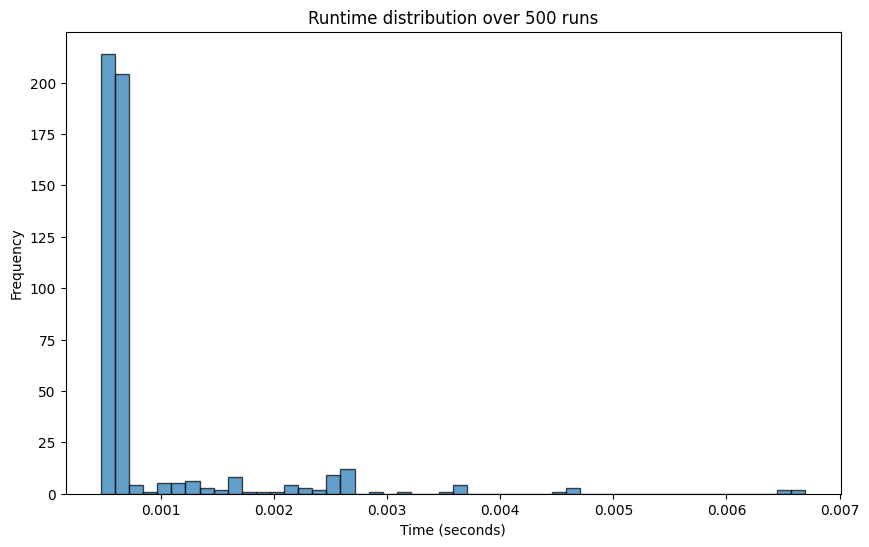

In [2]:
run_time_test(lambda: 1)
pass

### Check the GPU exists

In [3]:
import numba, torch
from numba import cuda

In [4]:
assert torch.cuda.is_available(), 'No GPU :(, go to Runtime, Change runtime type, and choose a GPU instance'

In [5]:
# Marvel at GPU specs
!nvidia-smi

Tue Sep 23 13:40:06 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   74C    P8             12W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
from numba import cuda
dev = cuda.get_current_device()

free, total = cuda.current_context().get_memory_info()

print("This is memory shared across the block, all threads can access")
print("Shared memory per block:", f'{dev.MAX_SHARED_MEMORY_PER_BLOCK / 1024:.2f}', 'KB', '\n')

print("These are very small and fixed to individual threads, ~4 bytes each")
print("Registers per block:", f'{dev.MAX_REGISTERS_PER_BLOCK}', '\n')

print("Threading limits:")
print("Max threads per block:", f'{dev.MAX_THREADS_PER_BLOCK}')
print("Max blocks per grid (x, y, z):", f'{dev.MAX_GRID_DIM_X}, {dev.MAX_GRID_DIM_Y}, {dev.MAX_GRID_DIM_Z}')
print("Number of multiprocessors:", f'{dev.MULTIPROCESSOR_COUNT}', '\n')

print('This is VRAM')
print("Total memory:", f'{total / 1024**3:.2f}', 'GB')


This is memory shared across the block, all threads can access
Shared memory per block: 48.00 KB 

These are very small and fixed to individual threads, ~4 bytes each
Registers per block: 65536 

Threading limits:
Max threads per block: 1024
Max blocks per grid (x, y, z): 2147483647, 65535, 65535
Number of multiprocessors: 40 

This is VRAM
Total memory: 14.74 GB


### Simple test
Lets do a element wise addition in
1. Numpy (CPU)
2. Pytorch
3. Plain python with numba

In [7]:
# Controls for running tests
size: int = 100_000
n: int = 100

  Mean  : 8.022393e-01 s  Median : 7.527697e-01 s Std Dev : 1.508963e-01 s 
  Min   : 7.182948e-01 s   Max   : 1.720993e+00 s 


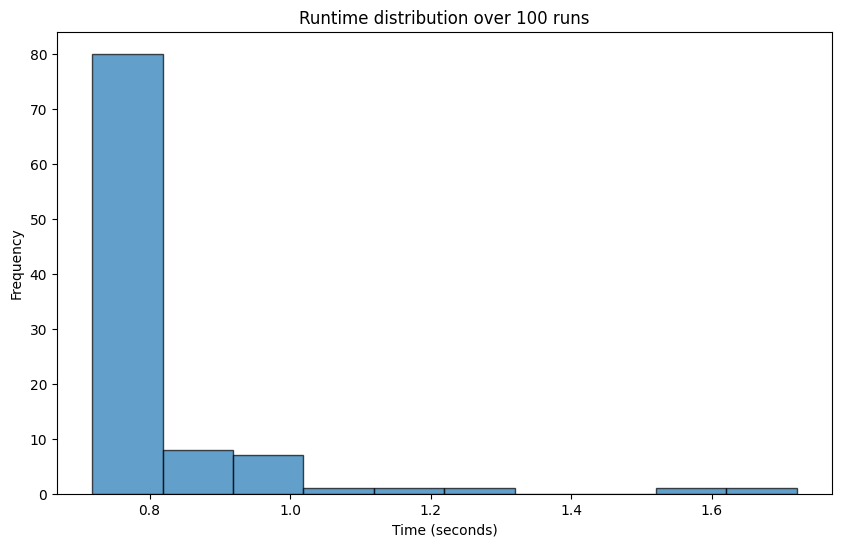

In [8]:
# Element wise addition using Numpy (CPU)

# Define test
def numpy_element_wise_addition(a: np.ndarray, b: np.ndarray) -> np.ndarray:

  return a + b

# Initialize variables
numpy_a: np.ndarray = np.random.random((size,))
numpy_b: np.ndarray = np.random.random((size,))

def numpy_test():
  numpy_element_wise_addition(numpy_a, numpy_b)

if input() == 'run': run_time_test(numpy_test, n=n)
pass

run
  Mean  : 9.162957e-02 s  Median : 7.966974e-02 s Std Dev : 3.036594e-02 s 
  Min   : 7.700408e-02 s   Max   : 2.371023e-01 s 


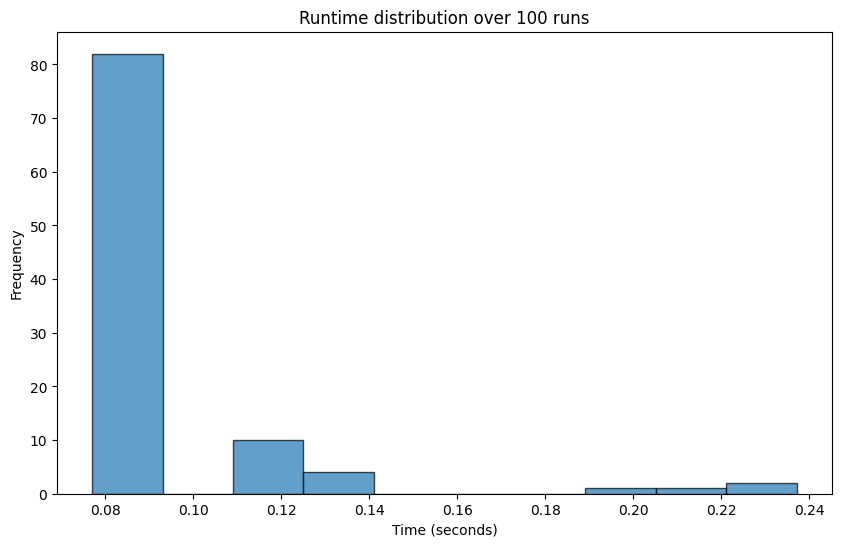

In [9]:
# In pytorch with gpu

def pytorch_element_wise_addition(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:

  return a + b

device = 'cuda'

torch_a: torch.Tensor = torch.randn((size,), device=device)
torch_b: torch.Tensor = torch.randn((size,), device=device)

def pytorch_test():
  torch_c = pytorch_element_wise_addition(torch_a, torch_b)

  # Time to copy to cpu for realism? (Takes a while)
  # c = c.to('cpu')

if input() == 'run': run_time_test(pytorch_test, n=n)
pass

run
  Mean  : 4.517509e-01 s  Median : 4.207576e-01 s Std Dev : 8.467851e-02 s 
  Min   : 4.047515e-01 s   Max   : 7.207231e-01 s 


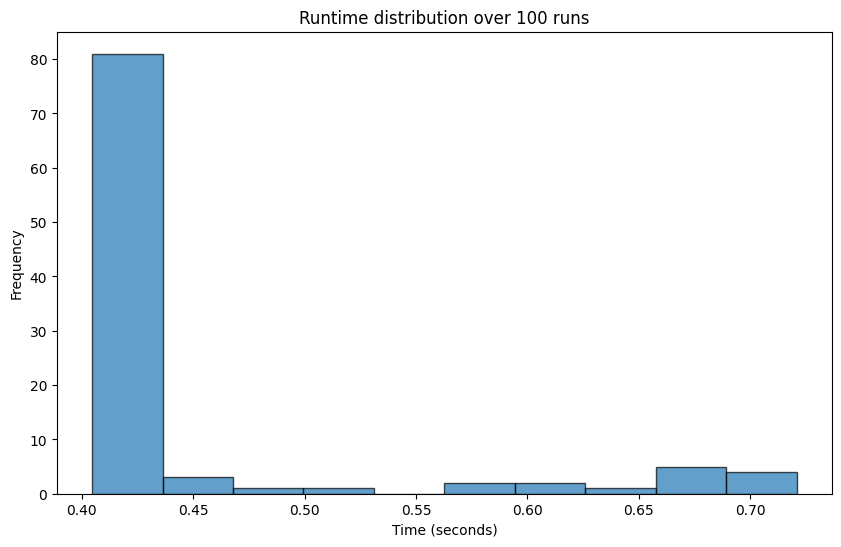

In [22]:
# Our own cuda kernel
from numba.cuda.cudadrv.devicearray import DeviceNDArray

from numba import config
config.CUDA_ENABLE_PYNVJITLINK = 1

@cuda.jit
def numba_element_wise_addition(
    a: DeviceNDArray,
    b: DeviceNDArray,
    c: DeviceNDArray, # <-- Will be empty we add results to this
    n: int, # <-- GPU look ups are slow
  ):

  # Our arrays are 1D, we must check we are still inbounds as 100,000 // 32 != 0
  pos = cuda.grid(1)

  if pos < n:
    c[pos] = a[pos] + b[pos]

  # Remember we can't return anything, we edit the given array
  return

# Same Initilization as Numpy
numpy_a: np.ndarray = np.random.random((size,))
numpy_b: np.ndarray = np.random.random((size,))

# Move to GPU
numba_a: DeviceNDArray = cuda.to_device(numpy_a)
numba_b: DeviceNDArray = cuda.to_device(numpy_b)

# Create return array
numba_c: DeviceNDArray = cuda.device_array_like(numba_a)

threads_per_block: int = 128 # Max is 1024, more threads means less memory per thread
# For blocks need to have enough threads to cover all elements of array, if cannot fit blocks parellel will run serial
blocks_in_grid: int = math.ceil(numba_a.size / threads_per_block)

numba_element_wise_addition[blocks_in_grid, threads_per_block](numba_a, numba_b, numba_c, numba_c.size)

# Transfers it to the cpu
# c = c.copy_to_host()

# Run test
def numba_test():

  numba_element_wise_addition[blocks_in_grid, threads_per_block](numba_a, numba_b, numba_c, numba_c.size)

  # c = c.copy_to_host(c)

if input() == 'run': run_time_test(numba_test, n=n)
pass

[numpy_test]   Mean  : 7.640441e-01 s  Median : 7.536311e-01 s Std Dev : 3.932617e-02 s 
[numpy_test]   Min   : 7.224389e-01 s   Max   : 9.843123e-01 s 
[pytorch_test]   Mean  : 8.597532e-02 s  Median : 7.868956e-02 s Std Dev : 1.381735e-02 s 
[pytorch_test]   Min   : 7.698019e-02 s   Max   : 1.289504e-01 s 
[numba_test]   Mean  : 4.204985e-01 s  Median : 3.892714e-01 s Std Dev : 8.246675e-02 s 
[numba_test]   Min   : 3.725791e-01 s   Max   : 6.656319e-01 s 


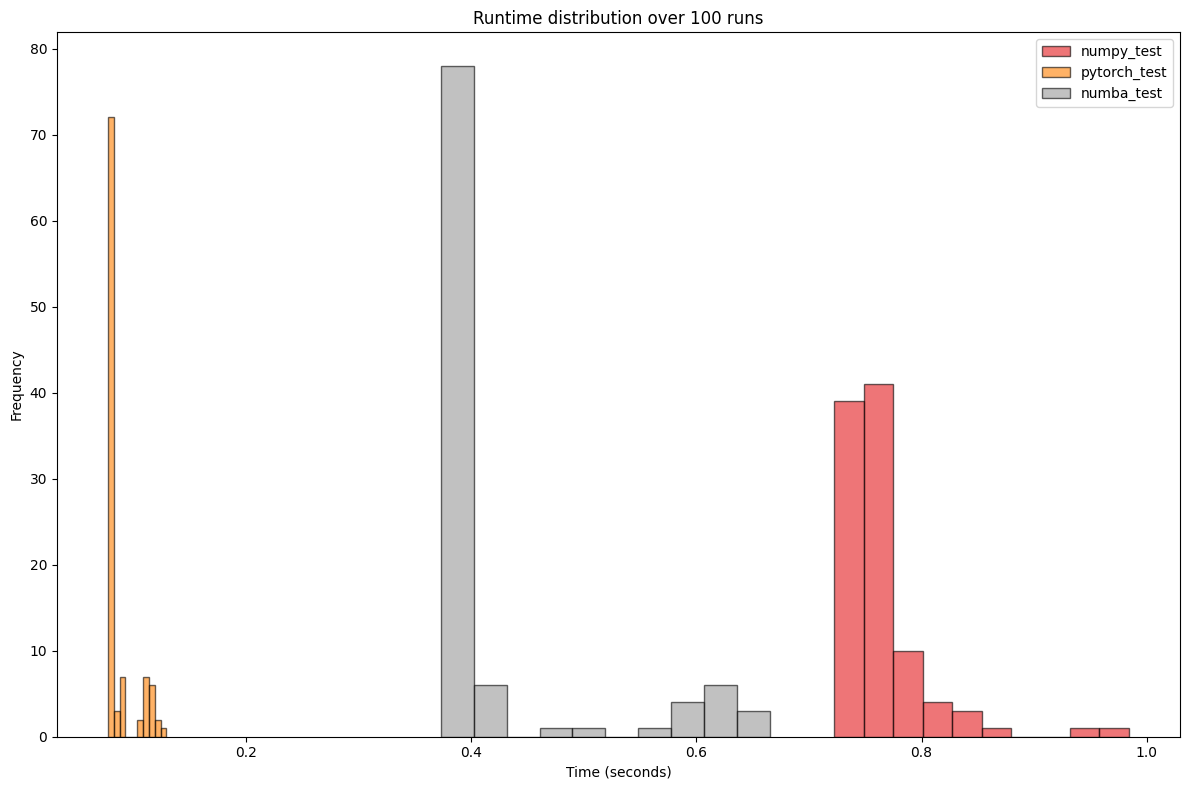

(<Figure size 1200x800 with 1 Axes>,
 <Axes: title={'center': 'Runtime distribution over 100 runs'}, xlabel='Time (seconds)', ylabel='Frequency'>)

In [11]:
# Do all 3
compare_functions(numpy_test, pytorch_test, numba_test, n=100)
pass